**1: Importing Necessary Libraries**

In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

**2: Data Preparation**

In [32]:
disease_df=pd.read_csv('framingham.csv')

**2.1 Loading and Handling Missing Values from the Dataset**

In [6]:
disease_df.dropna(axis=0,inplace=True)

In [7]:
disease_df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [8]:
disease_df.TenYearCHD.value_counts()

,count
TenYearCHD,
0,3101
1,557


In [9]:
disease_df.drop(columns=['education'],inplace=True,axis=1)

In [10]:
disease_df.rename(columns={'male':'Sex_male'},inplace=True)

In [11]:
disease_df.dropna(axis=0,inplace=True)

In [12]:
disease_df

,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


**3: Splitting the Dataset into Test and Train Sets**

In [13]:
X=np.asarray(disease_df[['age', 'Sex_male', 'cigsPerDay',
                           'totChol', 'sysBP', 'glucose']])
y=np.asarray(disease_df['TenYearCHD'])

In [16]:
from sklearn.preprocessing import StandardScaler

In [18]:
X=preprocessing.StandardScaler().fit(X).transform(X)

In [19]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=4)

In [21]:
print ('Train set:', x_train.shape,  y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (2560, 6) (2560,)
Test set: (1098, 6) (1098,)


**4: Exploratory Data Analysis of Heart Disease Dataset
4.1: Ten Year's CHD Record of all the patients available in the dataset:**

<ipython-input-22-2413258200>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TenYearCHD', data=disease_df,


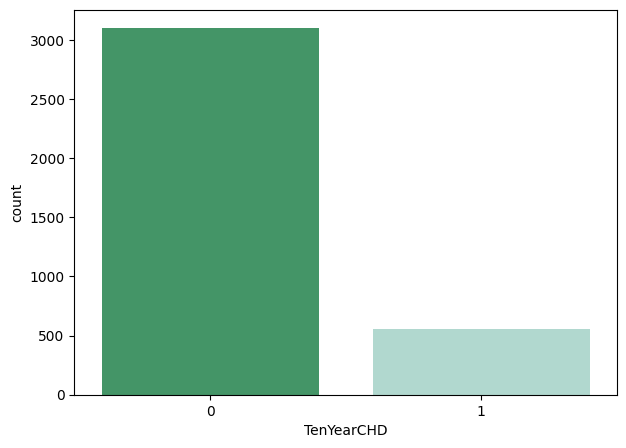

In [22]:
plt.figure(figsize=(7, 5))
sns.countplot(x='TenYearCHD', data=disease_df,
             palette="BuGn_r")
plt.show()

**4.2: Counting number of patients affected by CHD where (0= Not Affected; 1= Affected)**

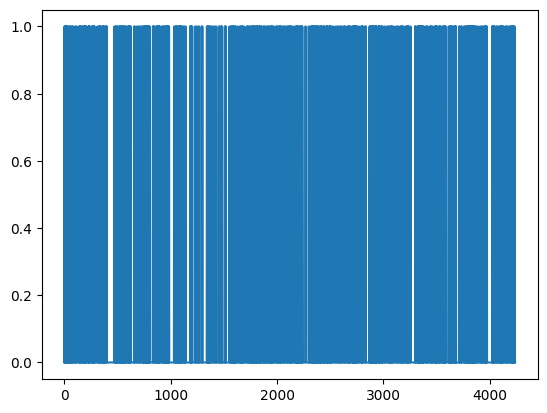

In [23]:
laste = disease_df['TenYearCHD'].plot()
plt.show(laste)

**5: Fitting Logistic Regression Model for Heart Disease Prediction**

In [24]:
logr=LogisticRegression()
logr.fit(x_train,y_train)

LogisticRegression()

In [25]:
y_pred=logr.predict(x_test)

**6: Evaluating Logistic Regression Model**

In [27]:
print("the accuracy score is ",accuracy_score(y_test,y_pred))

the accuracy score is  0.843351548269581


**7: Plotting Confusion Matrix**

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

In [29]:
print("The Detail for Confussion matric is:")
print(classification_report(y_test,y_pred))

The Detail for Confussion matric is:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       922
           1       0.60      0.07      0.12       176

    accuracy                           0.84      1098
   macro avg       0.72      0.53      0.52      1098
weighted avg       0.81      0.84      0.79      1098



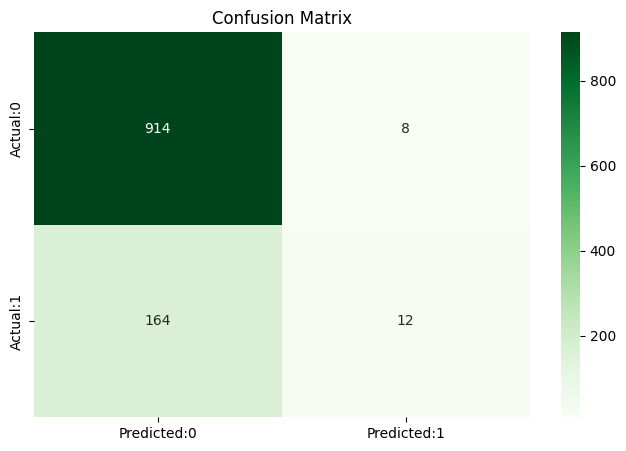

In [30]:
cm=confusion_matrix(y_test,y_pred)
conf_matrix=pd.DataFrame(data=cm,columns=['Predicted:0','Predicted:1'],index=['Actual:0','Actual:1'])
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Greens')
plt.title('Confusion Matrix')
plt.show()